# A conductance-based neuron

We consider a neuron with conductance-based synapses:

$$C \frac{dV}{dt} = -g_L(V-V_L) - g_e(V-V_e) - g_i(V-V_i)$$
$$\frac{dg_e}{dt} = -\frac{g_e}{\tau_e} + J_eS_e(t)$$
$$\frac{dg_i}{dt} = -\frac{g_i}{\tau_i} + J_iS_i(t)$$

where $S_e$ and $S_i$ are Poisson spike trains with rate $r_e$ and $r_i$ respectively. Here, $C$ is the membrane capacitance, $V_L,V_e,V_i$ are the reversal potentials of leak, excitatory, and inhibitory current, respectively, and $\tau_e,\tau_i$ are the synaptic time constants. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

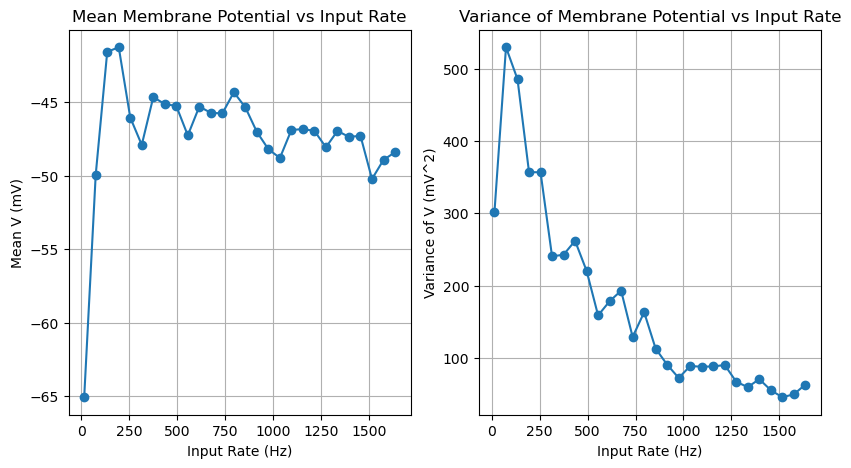

In [41]:
all_input_rates = []
all_mean_V = []
all_var_V = []
all_FF = []

plot_details = False

for base_rate in np.arange(5, 560, 20):

    # Time
    t_0 = 0.0
    T = 1000
    dt = 0.1
    time = np.arange(t_0, T, dt)

    # Neuron parameters
    g_L = 1
    E_L = -75.3
    tau_m = 15
    C = g_L * tau_m

    # Synapse parameters
    j_e = 0.7 * g_L
    j_i = 2.5 * g_L
    tau_e = 5
    tau_i = 8
    E_i = -70
    E_e = 10

    # Number of presynaptic neurons
    K_i = 1
    K_e = 1

    # Presynaptic firing rates
    r_i = base_rate / 1000
    r_e = 2 * r_i
    r = r_e + r_i

    # Synaptic weights
    J_e = j_e + np.zeros(K_e)
    J_i = j_i + np.zeros(K_i)

    # Spike densities
    S_e = np.random.binomial(1, r_e * dt, (K_e, len(time))) / dt
    S_i = np.random.binomial(1, r_i * dt, (K_i, len(time))) / dt

    # External input. Set to zero for now
    I0=0
    I_x=I0+np.zeros_like(time)

    # Initial conditions
    V0 = -72

    # Initialize voltage
    V = np.zeros_like(time)
    V[0] = E_L
    g_i = np.zeros_like(time)
    g_e = np.zeros_like(time)

    for n in range(len(time)-1):
        V[n + 1] = V[n] + dt * (1 / C) * (- g_L * (V[n] - E_L) - g_e[n] * (V[n] - E_e) - g_i[n] * (V[n] - E_i) + I_x[n])
        g_e[n + 1] = g_e[n] + dt * (1 / tau_e) * (-g_e[n]) + J_e @ S_e[:,n]
        g_i[n + 1] = g_i[n] + dt * (1 / tau_i) * (-g_i[n]) + J_i @ S_i[:,n]

    I_e = - g_e * (V - E_e)
    I_i = - g_i * (V - E_i)
    I_tot = I_e + I_i
    
    # Compute the mean and variance of V
    mean_V = np.mean(V)
    var_V = np.var(V)
    # FF = var_V / mean_V if mean_V != 0 else 0
    all_input_rates.append(r * 1000)  # Convert to Hz
    all_mean_V.append(mean_V)
    all_var_V.append(var_V)
    # all_FF.append(FF)

    # Extract spike times and trial numbers
    # to make raster plot
    [I,J]=np.nonzero(S_e)
    eSpikeTimes=J*dt
    eNeuronNumbers=I
    [I,J]=np.nonzero(S_i)
    iSpikeTimes=J*dt
    iNeuronNumbers=I
    
    if plot_details:

        # Create plots for S_e, S_i, I_e, I_i, and V in five subplots
        plt.subplots(8, 1, figsize=(10, 10))
        
        plt.suptitle(f'Conductance-based neuron with $r$={r*1000:.1f} Hz', fontsize=16)
        
        plt.subplot(8, 1, 1)
        
        plt.plot(eSpikeTimes,eNeuronNumbers,'r.',markersize=3)
        plt.title('Presynaptic Excitatory Spike Train', loc='left')
        plt.ylabel('exc. neuron\nindex')
        plt.xlabel('Time (ms)')


        plt.subplot(8, 1, 2)
        plt.plot(iSpikeTimes,iNeuronNumbers,'b.',markersize=3)
        plt.title('Presynaptic Inhibitory Spike Train', loc='left')
        plt.ylabel('inh. neuron\nindex')
        plt.xlabel('Time (ms)')

        plt.subplot(8, 1, 3)
        plt.plot(time, g_e, c='r')
        plt.title('Excitatory Synaptic Conductance $g_e$', loc='left')
        plt.ylabel('$g_e$ (mV)')
        plt.xlabel('Time (ms)')


        plt.subplot(8, 1, 4)
        plt.plot(time, g_i, c='b')
        plt.title('Inhibitory Synaptic Conductance $g_i$', loc='left')
        plt.ylabel('$g_i$ (mV)')
        plt.xlabel('Time (ms)')


        plt.subplot(8, 1, 5)
        plt.plot(time, I_e, c='r')
        plt.title('Excitatory Synaptic Current $I_e$', loc='left')
        plt.ylabel('$I_e$ (mV)')
        plt.xlabel('Time (ms)')


        plt.subplot(8, 1, 6)
        plt.plot(time, I_i, c='b')
        plt.title('Inhibitory Synaptic Current $I_i$', loc='left')
        plt.ylabel('$I_i$ (mV)')
        plt.xlabel('Time (ms)')

        plt.subplot(8, 1, 7)
        plt.plot(time, I_tot, c='grey')
        plt.title('Total Synaptic Current $I_{tot}$', loc='left')
        plt.ylabel('$I_{tot}$ (mV)')
        plt.xlabel('Time (ms)')

        plt.subplot(8, 1, 8)
        plt.plot(time, V, c='gray')
        plt.title('Membrane Potential', loc='left')
        plt.ylabel('V (mV)')
        plt.xlabel('Time (ms)')


        plt.tight_layout()
        plt.show()
    
    
# Plot mean_V, var_V, and FF as a function of input rate
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(all_input_rates, all_mean_V, 'o-')
plt.title('Mean Membrane Potential vs Input Rate')
plt.xlabel('Input Rate (Hz)')
plt.ylabel('Mean V (mV)')
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(all_input_rates, all_var_V, 'o-')
plt.title('Variance of Membrane Potential vs Input Rate')
plt.xlabel('Input Rate (Hz)')
plt.ylabel('Variance of V (mV^2)')
plt.grid()
# plt.subplot(1, 3, 3)
# plt.plot(all_input_rates, all_FF, 'o-')
# plt.title('Fano Factor of Membrane Potential vs Input Rate')
# plt.xlabel('Input Rate (Hz)')
# plt.ylabel('Fano Factor')
# plt.grid()
# plt.tight_layout()
plt.show()